## <font color='cornflowerblue'> Dependencies

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import vartools as vt
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'lightgray'

## <font color='cornflowerblue'> Optimal Weights

In [2]:
tickers = ['NVDA','AMZN','AVGO','PG','V','RL','GLD']

benchmark = 'SPY'
start_date = '2025-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

price = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close'][tickers]
benchmark_data = yf.download(benchmark, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close']

# Adjust optimization window
months = 3
n_days = round(len(benchmark_data) / round(len(benchmark_data) / 252 / (months / 12)), 0) 

# Benchmark
benchmark_data = benchmark_data.iloc[-int(n_days):, :]
rt_benchmark = benchmark_data.pct_change().dropna()

# Stocks
price = price.iloc[-int(n_days):, :]
rt = price.pct_change().dropna()

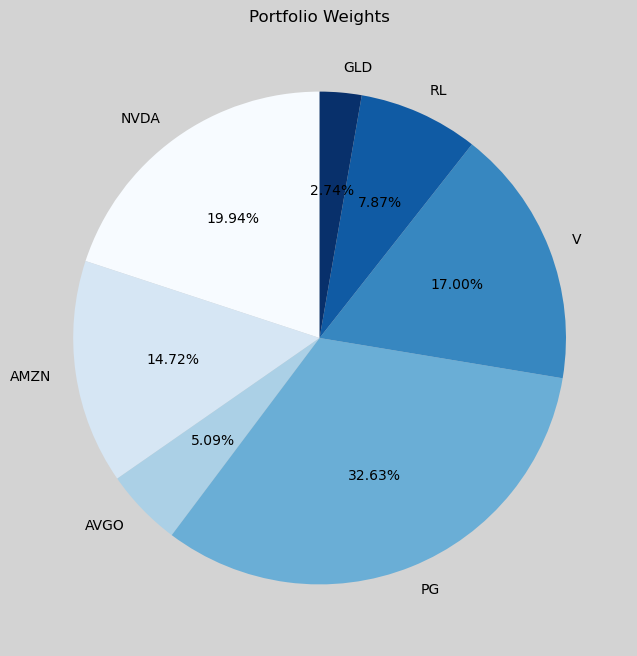

In [3]:
optimizer = vt.OptimizePortfolioWeights(rt, risk_free=0.0375)
weights = optimizer.opt_min_semivar(rt_benchmark)
vt.plot_weights(tickers, weights)

## <font color='cornflowerblue'> Rebalancing

In [4]:
pd.set_option('display.float_format', '{:.4f}'.format)

start_date = (datetime.today() - timedelta(days=3)).strftime('%Y-%m-%d')
end_date = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')

price = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close'][tickers]
#w_original = np.ones(len(tickers)) / len(tickers)
w_original = np.zeros(len(tickers))

rebalance_df = vt.rebalance_stocks(w_original=w_original,
                target_weights=weights,
                data=price,
                stocks=tickers,
                portfolio_value=1000)
rebalance_df

Ticker,NVDA,AMZN,AVGO,PG,V,RL,GLD
Peso Original,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Peso Óptimo,0.1994,0.1472,0.0509,0.3263,0.1700,0.0787,0.0274
Acciones (C/V),1.0434,0.6153,0.1537,2.1499,0.5283,0.2227,0.0616
